# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

from numpy.random import multivariate_normal, normal
import numpy as np
import matplotlib.pyplot as plt

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux 7d77d2247121 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [5]:
import helpers.hio as hio
import L09_05_04_non_linear_kalman_filter_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

In [6]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet filterpy)"

import filterpy

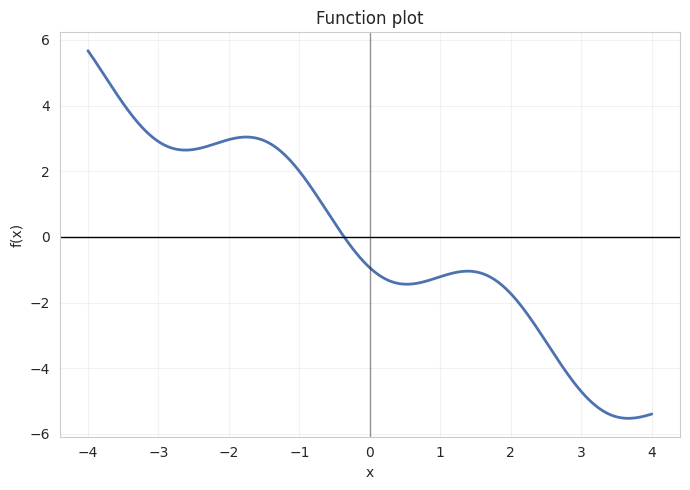

In [21]:
def f(x):
    return (np.cos(4 * (x / 2 + 0.7))) - 1.3 * x

    
time_ut.plot_function(f)

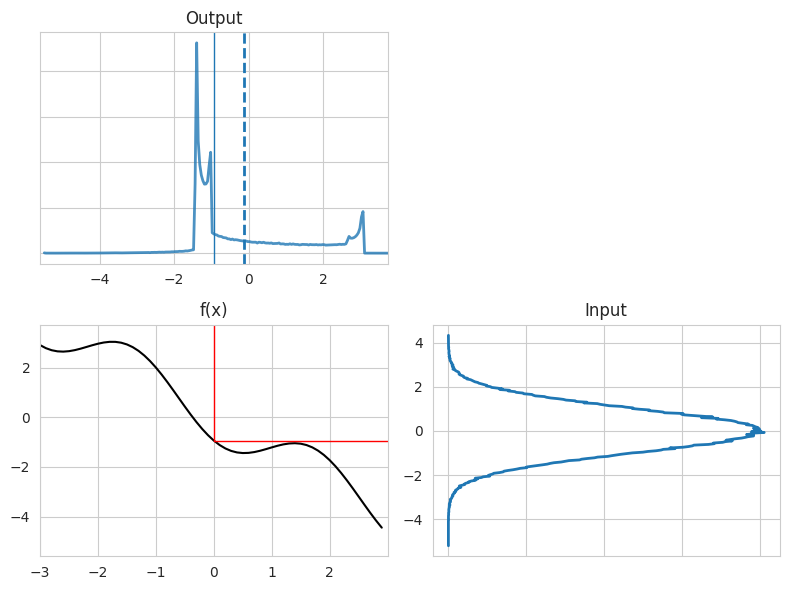

In [19]:
# Create 500,000 samples with mean 0, std 1.
gaussian = (0.0, 1.0)
data = normal(loc=gaussian[0], scale=gaussian[1], size=500000)

time_ut.plot_nonlinear_func(data, f)

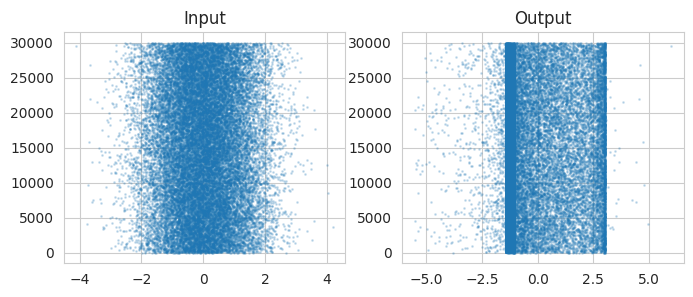

In [9]:
# Plot N points 
N = 30000
plt.subplot(121)
plt.scatter(data[:N], range(N), alpha=0.2, s=1)
plt.title("Input")
plt.subplot(122)
plt.title("Output")
plt.scatter(f(data[:N]), range(N), alpha=0.2, s=1)

In [29]:
def f_nonlinear_xy(x, y):
    return np.array([x + y, 0.1 * x**2 + y * y])

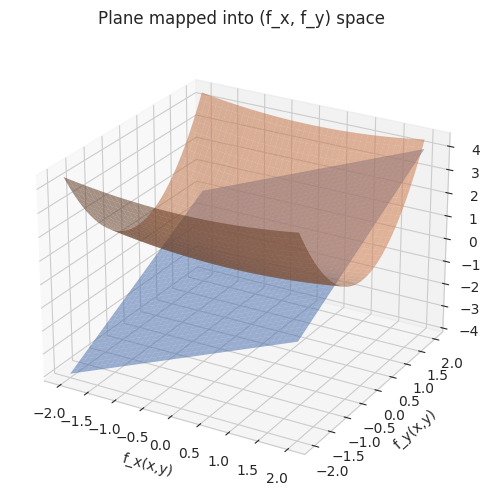

In [18]:
time_ut.plot_nonlinear_xy()

# 

# 

[0.24495349 0.02362951]
[ 0.24495349 42.83565061]


INFO:L09_05_04_non_linear_kalman_filter_utils:Difference in mean x=0.245, y=42.836


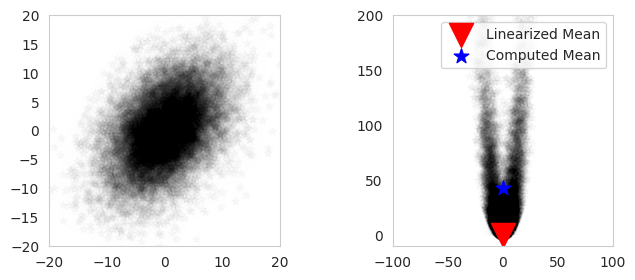

In [39]:
# Create a Gaussian.
N = 10000
mean = (0.0, 0.0)
p = np.array([[32.0, 15.0], [15.0, 40.0]])
xs, ys = multivariate_normal(mean=mean, cov=p, size=N).T

# Compute linearized mean.
mean1 = f_nonlinear_xy(np.mean(xs), np.mean(ys))
print("f(mean)=", mean1)
mean2 = np.mean([f_nonlinear_xy(xs_tmp, ys_tmp) for xs_tmp, ys_tmp in zip(xs, ys)], axis=0)
print("mean(f)=", mean2)

# Plot both.
time_ut.plot_monte_carlo_mean(xs, ys, f_nonlinear_xy, mean_fx, "Linearized Mean")

In [37]:
np.array([f_nonlinear_xy(xs_tmp, ys_tmp) for xs_tmp, ys_tmp in zip(xs, ys)])

array([[-3.39764284e+00,  1.74943261e+00],
       [-1.46993118e-01,  1.35294527e-02],
       [ 6.10441802e+00,  4.07276798e+00],
       ...,
       [ 1.12993073e+01,  6.03849876e+01],
       [-3.99731523e+00,  2.86877308e+01],
       [-1.22972401e+01,  1.03993312e+02]])

In [38]:
xs

array([-2.29105348, -0.03109328,  4.76026019, ...,  3.6129802 ,
        1.34194037, -2.12162301])